In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/perovskite/raw_data_b2.csv')
df2 = pd.read_csv('/content/drive/MyDrive/perovskite/raw_data_b3.csv')
df = pd.concat([df1,df2],ignore_index=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1219 entries, 0 to 1218
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 1219 non-null   int64  
 1   material_id                1219 non-null   object 
 2   formula                    1219 non-null   object 
 3   A                          1219 non-null   object 
 4   B1                         1219 non-null   object 
 5   B3                         1219 non-null   object 
 6   X                          1219 non-null   object 
 7   band_gap                   1219 non-null   float64
 8   formation_energy_per_atom  1219 non-null   float64
 9   e_above_hull               1219 non-null   float64
 10  R-A(pm)                    1219 non-null   float64
 11  I-A(kJ/mol)                1219 non-null   float64
 12  V-A                        1219 non-null   float64
 13  P-A                        1219 non-null   float

In [ ]:
df.drop(['Unnamed: 0','material_id','formula','A','B1','B3','X','formation_energy_per_atom','e_above_hull'],axis=1,inplace=True)

In [ ]:
correlation_with_band_gap = df.corr()['band_gap']
correlation_with_band_gap

,band_gap
band_gap,1.000000
R-A(pm),-0.032316
I-A(kJ/mol),-0.078645
V-A,NaN
P-A,0.031271
E-A(kJ/mol),-0.085950
N-A,-0.050887
R-B1(pm),0.117345
X-B1(kJ/mol),-0.187224
V-B1,-0.099050


In [ ]:
df.describe()

,band_gap,R-A(pm),I-A(kJ/mol),V-A,P-A,E-A(kJ/mol),N-A,R-B1(pm),X-B1(kJ/mol),V-B1,...,R-X(pm),X-X(kJ/mol),V-X,P-X,E-X(kJ/mol),A-X(kJ/mol),N-X,BE(A-X),BE(B1-X),BE(B3-X)
count,1219.000000,1219.000000,1219.000000,1219.0,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,...,1219.000000,1219.000000,1219.0,1219.000000,1219.000000,1219.000000,1219.000000,1219.000000,1120.000000,1046.000000
mean,2.595147,137.946678,430.432404,1.0,294.073306,99.012961,31.336341,107.652584,388.259943,2.074651,...,168.303527,3.409106,7.0,13.639065,99.600279,-328.253486,21.644791,445.243478,392.578125,420.549426
std,1.994926,29.915227,68.612169,0.0,91.757845,41.400609,18.351300,32.743130,305.967668,2.371181,...,32.679738,0.516367,0.0,10.121934,18.420984,15.980969,15.344570,72.703117,84.106134,110.209378
min,0.000000,73.000000,375.700000,1.0,48.120000,76.000000,3.000000,45.000000,0.890000,1.000000,...,133.000000,2.660000,7.0,3.740000,79.080000,-349.000000,9.000000,197.000000,159.000000,159.000000
25%,0.701550,138.000000,375.700000,1.0,290.100000,76.000000,19.000000,73.000000,1.910000,1.000000,...,133.000000,2.960000,7.0,3.740000,79.080000,-349.000000,9.000000,389.000000,335.000000,331.000000
50%,2.654300,152.000000,403.000000,1.0,319.200000,81.000000,37.000000,102.000000,418.800000,1.000000,...,181.000000,3.160000,7.0,14.600000,106.700000,-328.000000,17.000000,439.000000,394.000000,423.000000
75%,3.871500,167.000000,418.800000,1.0,400.000000,89.000000,55.000000,137.000000,731.000000,2.000000,...,196.000000,3.980000,7.0,21.600000,121.800000,-324.000000,35.000000,497.500000,448.000000,485.000000
max,8.319400,167.000000,745.500000,1.0,400.000000,338.000000,55.000000,167.000000,890.100000,10.000000,...,220.000000,3.980000,7.0,32.900000,121.800000,-295.000000,53.000000,574.900000,577.000000,664.000000


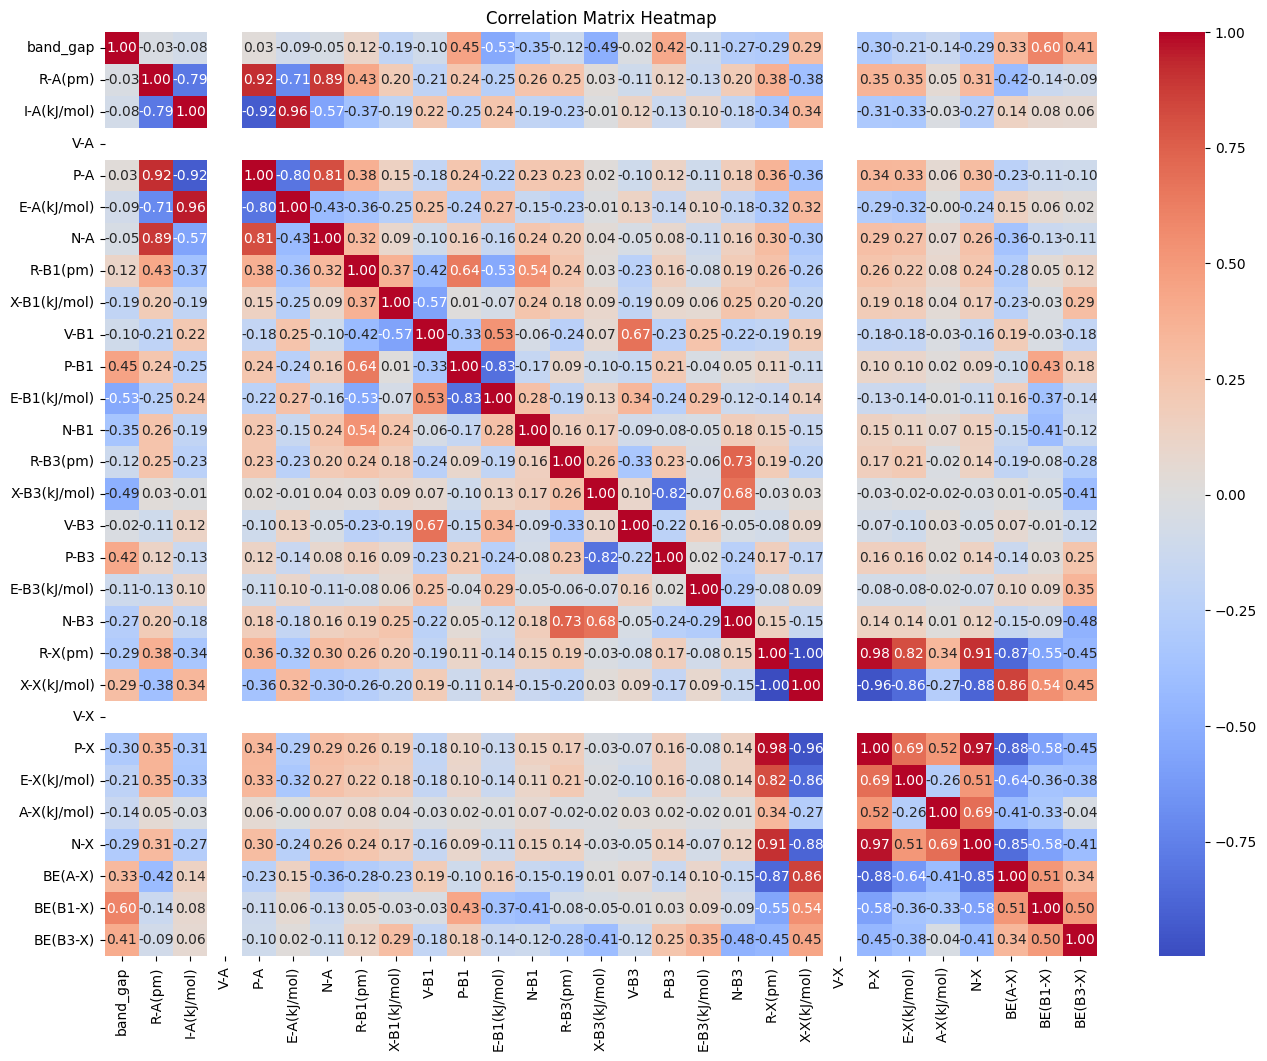

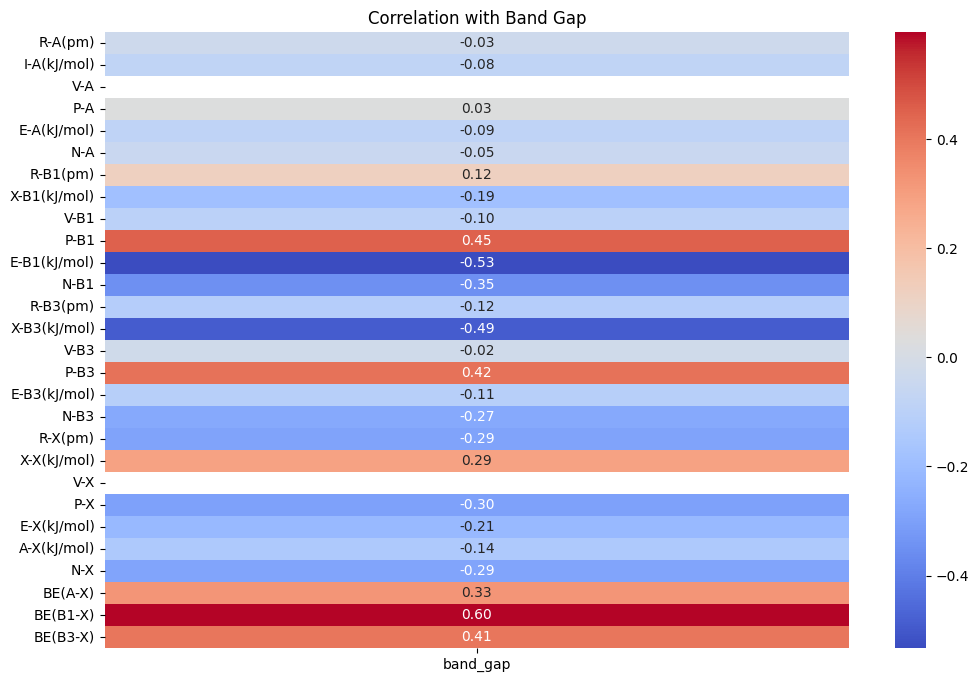

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

plt.figure(figsize=(12, 8))
correlation_with_band_gap = df.corr()['band_gap']
correlation_with_band_gap = correlation_with_band_gap.drop('band_gap')
sns.heatmap(correlation_with_band_gap.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Band Gap')
plt.show()


In [ ]:
df.columns

Index(['band_gap', 'R-A(pm)', 'I-A(kJ/mol)', 'V-A', 'P-A', 'E-A(kJ/mol)',
       'N-A', 'R-B1(pm)', 'X-B1(kJ/mol)', 'V-B1', 'P-B1', 'E-B1(kJ/mol)',
       'N-B1', 'R-B3(pm)', 'X-B3(kJ/mol)', 'V-B3', 'P-B3', 'E-B3(kJ/mol)',
       'N-B3', 'R-X(pm)', 'X-X(kJ/mol)', 'V-X', 'P-X', 'E-X(kJ/mol)',
       'A-X(kJ/mol)', 'N-X', 'BE(A-X)', 'BE(B1-X)', 'BE(B3-X)'],
      dtype='object')

In [ ]:
column_drop = ['V-A', 'P-A', 'E-A(kJ/mol)','N-A', 'X-B1(kJ/mol)','V-X','A-X(kJ/mol)']

In [ ]:
df.drop(column_drop,axis=1,inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings

In [ ]:
# train test spilt

y_total = df["band_gap"]
X_total = df.drop(["band_gap"],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.3,random_state=101)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import random
from deap import base, creator, tools, algorithms

# Ignore potential warnings from XGBoost
warnings.filterwarnings('ignore')

# --- Configuration ---
# Order: learning_rate, max_depth, n_estimators, subsample, reg_lambda, reg_alpha, gamma, colsample_bylevel, colsample_bytree
HP_BOUNDS_LOW = [0.01, 3, 50, 0.5, 0, 0, 0, 0.5, 0.5]
HP_BOUNDS_HIGH = [0.3, 15, 500, 1.0, 10, 10, 5, 1.0, 1.0]
# 0: continuous, 1: discrete
HP_TYPES = [0, 1, 1, 0, 0, 0, 0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability

# --- DEAP Setup ---
# Define the fitness function (minimize MSE)
# We use 'weights=(-1.0,)' because DEAP minimizes by default, and we want to minimize MSE
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# Define the individual (a list of hyperparameters)
# The individual will have the defined fitness attribute
creator.create("Individual", list, fitness=creator.FitnessMin)

# Create a toolbox to hold the evolutionary operators
toolbox = base.Toolbox()

# Attribute generator: Generate a random value within the bounds for each hyperparameter
# This function will be used to create the initial population
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register the attribute generator for each hyperparameter
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer: Create an individual by combining the attributes
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)

# Population initializer: Create a list of individuals
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalXGBR(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training an XGBoost Regressor and calculating the Mean Squared Error
    on the validation set.
    """

    hyperparameters = {
        'learning_rate': individual[0],
        'max_depth': int(individual[1]),
        'n_estimators': int(individual[2]),
        'subsample': individual[3],
        'reg_lambda': individual[4],
        'reg_alpha': individual[5],
        'gamma': individual[6],
        'colsample_bylevel': individual[7],
        'colsample_bytree': individual[8]
    }

    # Ensure max_depth and n_estimators are at least 1
    hyperparameters['max_depth'] = max(1, hyperparameters['max_depth'])
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])


    try:

        model = XGBRegressor(objective='reg:squarederror',
                                 eval_metric='rmse',
                                 use_label_encoder=False, # Deprecated warning fix
                                 random_state=42,
                                 **hyperparameters)


        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)

    except Exception as e:
        # Handle potential errors during training ( invalid hyperparameters)
        return (float('inf'),) # Assign infinity as fitness

# Register the evaluation function with the toolbox
toolbox.register("evaluate", evalXGBR, X_train=None, y_train=None, X_val=None, y_val=None) # Will set data later

# --- Genetic Operators ---
# Register the crossover operator
toolbox.register("mate", tools.cxTwoPoint)

# Register the mutation operator (Gaussian mutation)
# We use a custom mutation to respect the bounds and types of hyperparameters
def mutate_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb: # Mutate with probability indpb
            if hp_type == 0:
                # Apply Gaussian mutation
                individual[i] += random.gauss(mu, sigma[i])
                # Ensure bounds are respected
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:
                # Apply integer mutation (add random integer within a range)

                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

# Register the custom mutation operator
# Adjust sigma based on the range of each hyperparameter
hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges] # mutation strength is 10% of the range
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1) # indpb is the probability of mutating each attribute

# Register the selection operator (tournament selection)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Evolutionary Loop ---
if __name__ == '__main__':

    # Update the toolbox with the actual data
    toolbox.unregister("evaluate") # Unregister the placeholder
    toolbox.register("evaluate", evalXGBR, X_train=X_train_scaled, y_train=y_train, X_val=X_test_scaled, y_val=y_test)

    # Create the initial population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Evaluate the fitness of the initial population
    print("Evaluating initial population...")
    # Map the evaluation function to the individuals
    fitnesses = list(map(toolbox.evaluate, population))
    # Assign the calculated fitness values to the individuals
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1) # Hall of Fame to store the single best individual

    # Create a statistics object to record performance during evolution
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Run the evolutionary algorithm
    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                              ngen=NUM_GENERATIONS, stats=stats,
                                              halloffame=hof, verbose=True)


    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]

        # Decode the best hyperparameters
        optimal_hyperparameters = {
            'learning_rate': best_individual[0],
            'max_depth': int(best_individual[1]),
            'n_estimators': int(best_individual[2]),
            'subsample': best_individual[3],
            'reg_lambda': best_individual[4],
            'reg_alpha': best_individual[5],
            'gamma': best_individual[6],
            'colsample_bylevel': best_individual[7],
            'colsample_bytree': best_individual[8]
        }

        print(f"Optimization finished. Best Mean Squared Error: {optimal_objective:.4f}")
        print("Optimal Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")

    else:
        print("Optimization did not find a valid individual.")



Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std   	min     	max    
0  	0     	0.454797	0.1634	0.301741	1.21524
1  	39    	0.381045	0.0489944	0.292179	0.476783
2  	37    	0.334475	0.0256391	0.284562	0.410314
3  	40    	0.317358	0.0213004	0.284167	0.377742
4  	41    	0.309957	0.0166513	0.284167	0.364677
5  	37    	0.304751	0.0205497	0.279673	0.392175
6  	34    	0.296493	0.011293 	0.279673	0.335768
7  	40    	0.300002	0.013536 	0.275435	0.344054
8  	45    	0.300468	0.0147626	0.279673	0.354006
9  	46    	0.29464 	0.0122568	0.279673	0.336785
10 	38    	0.29518 	0.0167935	0.278511	0.373247
11 	44    	0.29407 	0.0124037	0.278511	0.32789 
12 	45    	0.290811	0.00920746	0.278511	0.311068
13 	42    	0.287963	0.0105763 	0.274638	0.337995
14 	34    	0.287148	0.00905427	0.274638	0.315015
15 	40    	0.285413	0.00859604	0.274638	0.306305
16 	39    	0.285488	0.0117448 	0.274638	0.344035
17 	40 

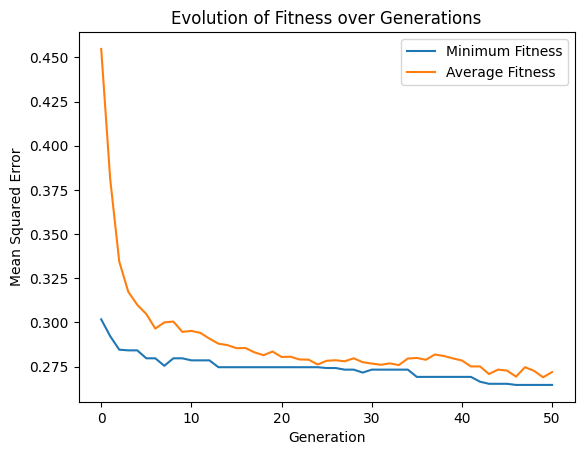

In [ ]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

In [ ]:
final_model = XGBRegressor(objective='reg:squarederror',
                                use_label_encoder=False,
                                random_state=42,
                                **optimal_hyperparameters)
final_model.fit(X_train_scaled, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.


In [ ]:


y_pred = final_model.predict(X_test_scaled)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.2646
Test set Root Mean Squared Error (RMSE): 0.5144
Test set R-squared (R2): 0.9317


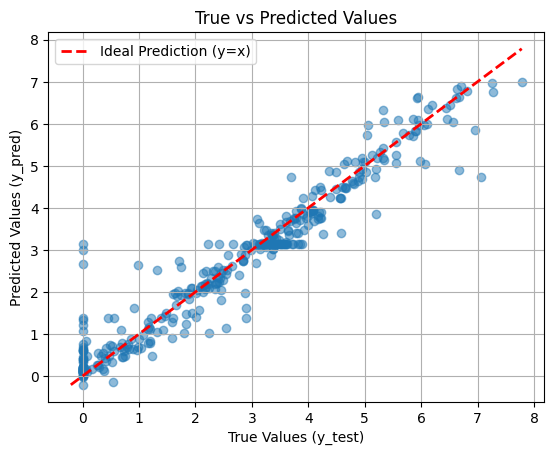

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)


plt.title('True vs Predicted Values')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# saving model

import joblib

filename = '/content/drive/MyDrive/colab-model/XGBR_deap_perovskites.joblib'
joblib.dump(final_model, filename)

print(f"Model saved successfully to {filename}")

Model saved successfully to /content/drive/MyDrive/colab-model/XGBR_deap_perovskites.joblib


In [ ]:
# savine scaler
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/colab-model/XGBR_deap_perovskites_scaler.pkl')

['/content/drive/MyDrive/colab-model/XGBR_deap_perovskites_scaler.pkl']

In [ ]:
import random
import numpy as np
import warnings
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

# --- Configuration ---
# Order: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
HP_BOUNDS_LOW =  [50,  2,  2,  1, 0.1]
HP_BOUNDS_HIGH = [500, 20, 20, 10, 1.0]
# 0 = continuous, 1 = discrete
HP_TYPES = [1, 1, 1, 1, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 30
NUM_GENERATIONS = 20
CXPB = 0.7  # Crossover probability
MUTPB = 0.3  # Mutation probability

# --- DEAP Setup ---
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register attributes
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializers
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalRFR(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training a RandomForestRegressor and calculating the MSE
    on the validation set.
    """

    hyperparameters = {
        "n_estimators": int(individual[0]),
        "max_depth": int(individual[1]),
        "min_samples_split": int(individual[2]),
        "min_samples_leaf": int(individual[3]),
        "max_features": individual[4],
        "random_state": 42,
        "n_jobs": -1,
    }

    try:
        model = RandomForestRegressor(**hyperparameters)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)

    except Exception:
        return (float("inf"),)

# Register the evaluation function placeholder
toolbox.register("evaluate", evalRFR, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:  # continuous
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:  # integer
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Loop ---
if __name__ == "__main__":
    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler


    # Update evaluate function with actual data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalRFR, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    print("Evaluating initial population...")
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True
    )

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]
        optimal_hyperparameters = {
            "n_estimators": int(best_individual[0]),
            "max_depth": int(best_individual[1]),
            "min_samples_split": int(best_individual[2]),
            "min_samples_leaf": int(best_individual[3]),
            "max_features": best_individual[4],
        }

        print(f"Best Mean Squared Error: {optimal_objective:.4f}")
        print("Best Hyperparameters:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("No valid individual found.")


Creating initial population of size 30...
Evaluating initial population...
Starting evolutionary optimization for 20 generations...
gen	nevals	avg     	std     	min     	max    
0  	0     	0.461274	0.251603	0.304853	1.41614
1  	22    	0.357817	0.097213	0.299703	0.841397
2  	25    	0.321275	0.0224887	0.300705	0.388835
3  	23    	0.312527	0.0243385	0.297478	0.428121
4  	24    	0.301744	0.00493728	0.295258	0.318909
5  	24    	0.312688	0.0560682 	0.295258	0.598504
6  	24    	0.302447	0.0125344 	0.295258	0.355745
7  	24    	0.300734	0.0157582 	0.295258	0.385296
8  	21    	0.298428	0.00494144	0.295258	0.323325
9  	19    	0.300646	0.0184586 	0.295258	0.398183
10 	26    	0.299548	0.010192  	0.294804	0.33874 
11 	27    	0.299854	0.0118859 	0.295258	0.341639
12 	29    	0.297233	0.00839395	0.295258	0.341606
13 	19    	0.298489	0.0100143 	0.295258	0.341417
14 	23    	0.295849	0.00125616	0.295258	0.299742
15 	27    	0.301748	0.0156518 	0.295258	0.349021
16 	28    	0.345692	0.201185  	0.295258	1.407

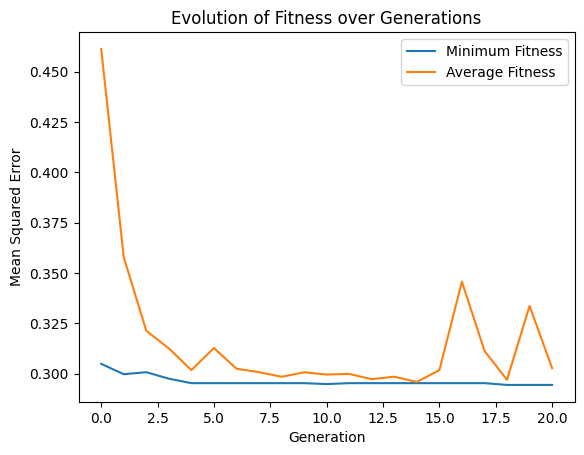

In [ ]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations")
plt.legend()
plt.show()

In [ ]:
final_model_random = RandomForestRegressor(random_state=42,
                                **optimal_hyperparameters)
final_model_random.fit(X_train, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.


In [ ]:
y_pred = final_model_random.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.2944
Test set Root Mean Squared Error (RMSE): 0.5426
Test set R-squared (R2): 0.9241


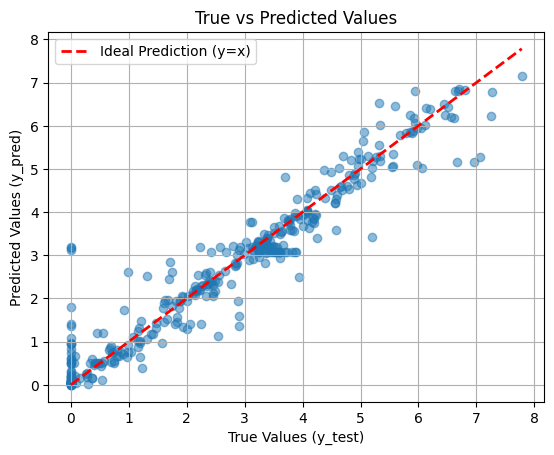

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)


plt.title('True vs Predicted Values')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import joblib

#can choose a strategy: 'mean', 'median', 'most_frequent', or 'constant'
imputer = SimpleImputer(strategy='mean') # Common choice for numerical data


X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 5. (Optional but HIGHLY Recommended for SVR) Feature Scaling
scaler = joblib.load('/content/drive/MyDrive/colab-model/XGBR_deap_perovskites_scaler.pkl')
X_train_processed = scaler.transform(X_train_imputed)
X_test_processed = scaler.transform(X_test_imputed)

# Now, when you call your GA, make sure to pass these processed arrays:
# toolbox.register("evaluate", evalSVR, X_train=X_train_processed, y_train=y_train, X_val=X_test_processed, y_val=y_test)

# Verify no NaNs remain (should output 0 for both)
print(f"Number of NaNs in X_train_processed after imputation: {np.isnan(X_train_processed).sum()}")
print(f"Number of NaNs in X_test_processed after imputation: {np.isnan(X_test_processed).sum()}")

Number of NaNs in X_train_processed after imputation: 0
Number of NaNs in X_test_processed after imputation: 0


In [ ]:
import random
import warnings
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Ignore potential warnings
warnings.filterwarnings('ignore')

# --- Configuration for SVR ---
# Order: C, epsilon, gamma (kernel will be 'rbf' for simplicity, or you can add it as a discrete HP)
SVR_HP_BOUNDS_LOW = [0.1, 0.01, 0.001]
SVR_HP_BOUNDS_HIGH = [100, 1.0, 1.0]
# 0: continuous, 1: discrete (none for these SVR HPs)
SVR_HP_TYPES = [0, 0, 0]
NUM_SVR_HYPERPARAMETERS = len(SVR_HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters (can be the same as before)
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability

# --- DEAP Setup ---
# Define the fitness function (minimize MSE)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# Attribute generator for SVR hyperparameters
def generate_svr_hyperparameter(index):
    low = SVR_HP_BOUNDS_LOW[index]
    high = SVR_HP_BOUNDS_HIGH[index]
    if SVR_HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register the attribute generator for each SVR hyperparameter
for i in range(NUM_SVR_HYPERPARAMETERS):
    toolbox.register(f"attr_svr_hp{i}", generate_svr_hyperparameter, i)

# Structure initializer: Create an individual for SVR
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_svr_hp{i}") for i in range(NUM_SVR_HYPERPARAMETERS)]), n=1)

# Population initializer
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function for SVR ---
def evalSVR(individual, X_train, y_train, X_val, y_val):
    hyperparameters = {
        'C': individual[0],
        'epsilon': individual[1],
        'gamma': individual[2],
        'kernel': 'rbf'
    }

    try:
        model = SVR(**hyperparameters)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)
    except Exception as e:
        print(f"Error evaluating SVR with HPs {hyperparameters}: {e}") # <-- UNCOMMENT THIS LINE
        return (float('inf'),)

# Register the evaluation function
toolbox.register("evaluate", evalSVR, X_train=None, y_train=None, X_val=None, y_val=None) # Will set data later

# --- Genetic Operators for SVR HPs ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_svr_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's SVR hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(SVR_HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0: # Continuous
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(SVR_HP_BOUNDS_LOW[i], min(SVR_HP_BOUNDS_HIGH[i], individual[i]))
            else: # Discrete (though none for current SVR setup)
                individual[i] = random.randint(SVR_HP_BOUNDS_LOW[i], SVR_HP_BOUNDS_HIGH[i])
    return individual,

svr_hp_ranges = [high - low for low, high in zip(SVR_HP_BOUNDS_LOW, SVR_HP_BOUNDS_HIGH)]
svr_mutation_sigma = [r * 0.1 for r in svr_hp_ranges]
toolbox.register("mutate", mutate_svr_hyperparameters, mu=0, sigma=svr_mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Main Evolutionary Loop ---
if __name__ == '__main__':
    # Make sure X_train, y_train, X_test, y_test are defined in an earlier cell
    # before running this cell.

    # Update the toolbox with the actual data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalSVR, X_train=X_train_processed, y_train=y_train, X_val=X_test_processed, y_val=y_test)

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    print("Evaluating initial population...")
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                              ngen=NUM_GENERATIONS, stats=stats,
                                              halloffame=hof, verbose=True)

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]

        optimal_hyperparameters = {
            'C': best_individual[0],
            'epsilon': best_individual[1],
            'gamma': best_individual[2],
            'kernel': 'rbf'
        }

        print(f"Optimization finished. Best Mean Squared Error: {optimal_objective:.4f}")
        print("Optimal SVR Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("Optimization did not find a valid individual.")

Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std     	min     	max    
0  	0     	0.840885	0.419412	0.293399	2.96618
1  	41    	0.54643 	0.153251	0.302571	0.928291
2  	39    	0.422968	0.0764037	0.297659	0.707178
3  	41    	0.372302	0.0435376	0.297659	0.528525
4  	40    	0.345909	0.0311089	0.293318	0.445532
5  	38    	0.330557	0.0242677	0.293318	0.398214
6  	37    	0.318368	0.0211094	0.293318	0.38262 
7  	39    	0.30432 	0.0129284	0.293318	0.365439
8  	40    	0.296791	0.00471795	0.293318	0.321705
9  	39    	0.299025	0.0280552 	0.293318	0.490952
10 	41    	0.296522	0.0121447 	0.293318	0.365465
11 	41    	0.305909	0.086946  	0.293318	0.91449 
12 	41    	0.295763	0.0133091 	0.293318	0.386113
13 	33    	0.297995	0.016317  	0.293318	0.37084 
14 	43    	0.295637	0.0112479 	0.293318	0.365498
15 	38    	0.293456	0.00094371	0.293318	0.300061
16 	45    	0.294993	0.010771  	0.293318	0.370242


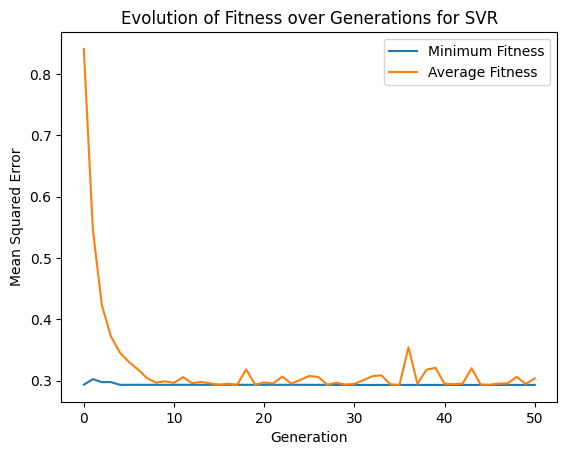

In [ ]:
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for SVR")
plt.legend()
plt.show()

In [ ]:
from sklearn.svm import SVR


# 'C', 'epsilon', 'gamma', and 'kernel' (e.g., {'C': ..., 'epsilon': ..., 'gamma': ..., 'kernel': 'rbf'})
# and X_train, y_train are your preprocessed training data.

final_svr_model = SVR(
    C=optimal_hyperparameters['C'],
    epsilon=optimal_hyperparameters['epsilon'],
    gamma=optimal_hyperparameters['gamma'],
    kernel=optimal_hyperparameters['kernel'] # This will be 'rbf' based on our setup
)

# Fit the SVR model using your preprocessed training data
final_svr_model.fit(X_train_processed, y_train)

print("\nFinal SVR model trained with optimal hyperparameters.")


Final SVR model trained with optimal hyperparameters.


In [ ]:
y_pred = final_svr_model.predict(X_test_processed)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.2931
Test set Root Mean Squared Error (RMSE): 0.5414
Test set R-squared (R2): 0.9244


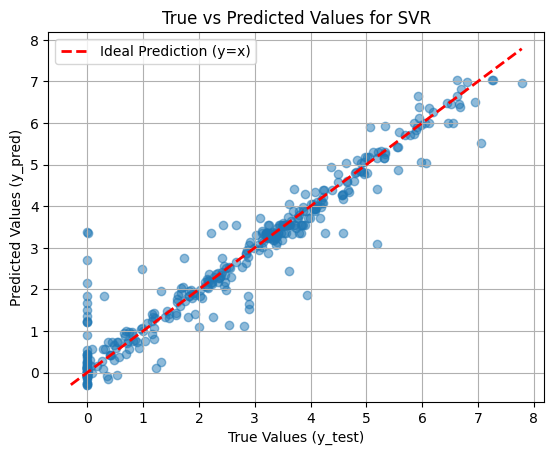

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)


plt.title('True vs Predicted Values for SVR')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()